In [10]:
# Import Library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from scipy.stats import shapiro



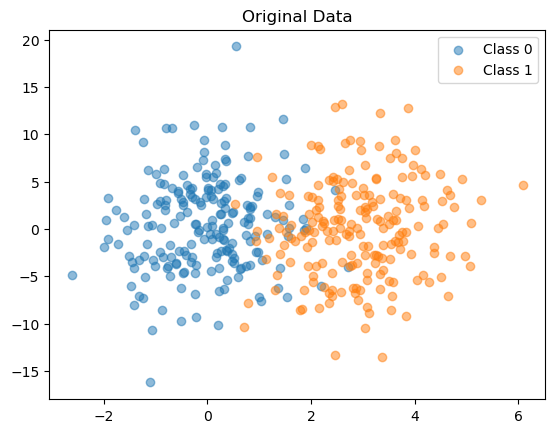

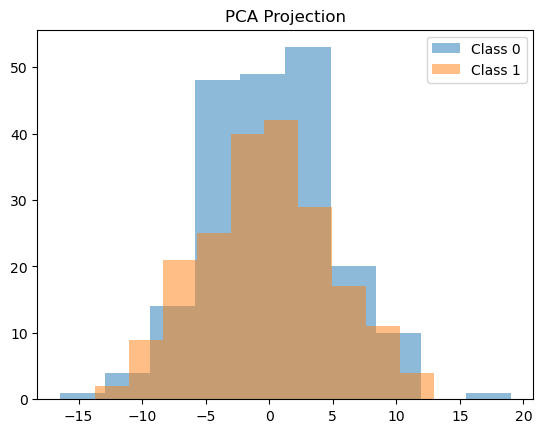

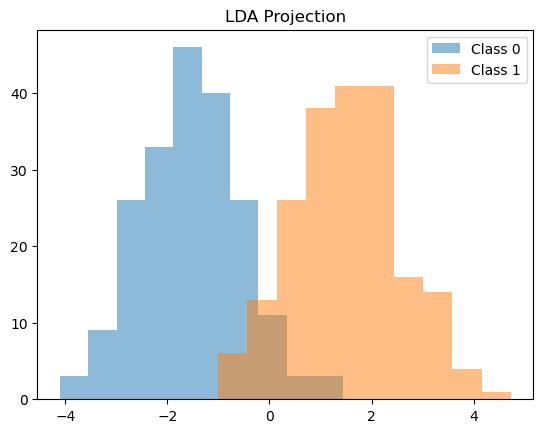

In [11]:
np.random.seed(42)

# Generate data
n = 200

# Class 0
x0 = np.random.normal(loc=0, scale=1, size=n)
y0 = np.random.normal(loc=0, scale=5, size=n)

# Class 1
x1 = np.random.normal(loc=3, scale=1, size=n)
y1 = np.random.normal(loc=0, scale=5, size=n)

X = np.vstack((np.column_stack((x0, y0)),
               np.column_stack((x1, y1))))
y = np.array([0]*n + [1]*n)

# Plot original data
plt.scatter(x0, y0, label="Class 0", alpha=0.5)
plt.scatter(x1, y1, label="Class 1", alpha=0.5)
plt.legend()
plt.title("Original Data")
plt.show()

# PCA
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X)

# LDA
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X, y)

# Plot projections
plt.hist(X_pca[y==0], alpha=0.5, label="Class 0")
plt.hist(X_pca[y==1], alpha=0.5, label="Class 1")
plt.title("PCA Projection")
plt.legend()
plt.show()

plt.hist(X_lda[y==0], alpha=0.5, label="Class 0")
plt.hist(X_lda[y==1], alpha=0.5, label="Class 1")
plt.title("LDA Projection")
plt.legend()
plt.show()


In [12]:
#Questions :

#1.	Why does PCA choose the wrong direction here? 
# Answer: In class 0 and 1, mean for X0 and X1 are at 0 and 3 (with scale 1), 
# wherein mean for y0 and y1 are at 0 and 0 with scale 5. 
# It means spread of data along Y axis is much larger than X axis (sclae 5 Vs scale 1).
# Hence, PCA selects Y axis as the principle direction. 
# but the mean of both the classes along y axis i.e., y0 and y1, is at 0.   
#2.	What information is PCA missing? 
# Answer: Class mean
#3.	How does LDA use labels to fix this? 
# 
#4.	What would happen if class means were identical? 


### Re-created data set by changing X-axis scale from 1 to 5
### This is done to have uniform spread

Mean of x0: -0.0815
Mean of y0: 0.1717
Mean of x1: 2.8287
Mean of y1: 0.0179


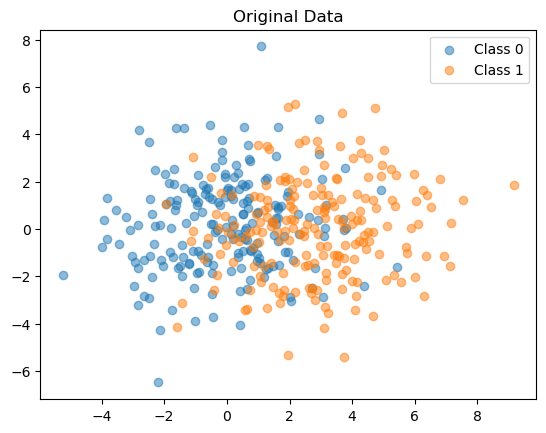

In [13]:
np.random.seed(42)

# Generate data
n = 200

# Class 0
x0 = np.random.normal(loc=0, scale=2, size=n)
y0 = np.random.normal(loc=0, scale=2, size=n)

# Calculate means for Class 0
mean_x0 = np.mean(x0)
mean_y0 = np.mean(y0)

# Optional: Print them to check the values
print(f"Mean of x0: {mean_x0:.4f}")
print(f"Mean of y0: {mean_y0:.4f}")

# Class 1
x1 = np.random.normal(loc=3, scale=2, size=n)
y1 = np.random.normal(loc=0, scale=2, size=n)

# Calculate means for Class 0
mean_x1 = np.mean(x1)
mean_y1 = np.mean(y1)

# Optional: Print them to check the values
print(f"Mean of x1: {mean_x1:.4f}")
print(f"Mean of y1: {mean_y1:.4f}")

X = np.vstack((np.column_stack((x0, y0)),
               np.column_stack((x1, y1))))
y = np.array([0]*n + [1]*n)

# Plot original data
plt.scatter(x0, y0, label="Class 0", alpha=0.5)
plt.scatter(x1, y1, label="Class 1", alpha=0.5)
plt.legend()
plt.title("Original Data")
plt.show()


In [14]:
# PCA
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X)

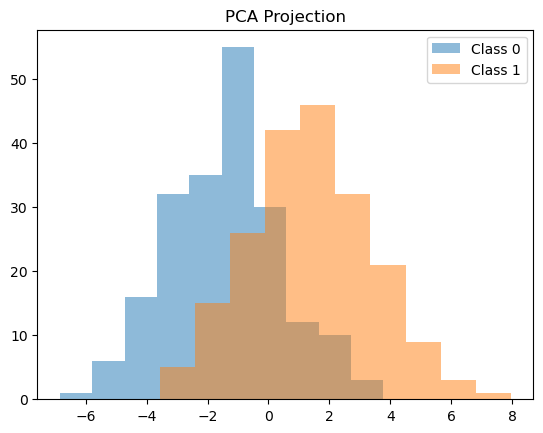

In [15]:
# Plot projections
plt.hist(X_pca[y==0], alpha=0.5, label="Class 0")
plt.hist(X_pca[y==1], alpha=0.5, label="Class 1")
plt.title("PCA Projection")
plt.legend()
plt.show()

## Import dataset Ida_gaussian

In [16]:
# Import dataset Ida_gaussian
data = pd.read_csv(r"D:\GenAI\IIT M Pravartak\Content\Assignment\2. 11-Apr-26_LDA\lda_gaussian.csv")
data.head()

,Feature1,Feature2,Label
0,5.147623,1.350238,1
1,5.597768,-0.519110,1
2,-2.529443,7.427720,0
3,5.460525,1.669881,1
4,5.074541,5.086271,1


In [20]:
unique_values = np.unique(y)
print(unique_values)
# unique_label = y.nunique()
# print(unique_label)

[0 1]


In [21]:
data.shape

(300, 3)

In [22]:
# Seperate X and y
# Drop Label from data
X = data.drop(columns=['Label'])
# Select Label
y = data['Label']

In [23]:
X.head()

,Feature1,Feature2
0,5.147623,1.350238
1,5.597768,-0.519110
2,-2.529443,7.427720
3,5.460525,1.669881
4,5.074541,5.086271


In [24]:
print(y.head())

0    1
1    1
2    0
3    1
4    1
Name: Label, dtype: int64


In [25]:
# Calculate PCA without using PCA Library
# Steps involved: 
# Step 1: Scale and center data around mean
# Step 2: Create covariance matrix
# Step 3 Calculate eigenvalues and eigenvectors from the covariance matrix. The eigenvectors define the Principal Components (PC1, PC2). They are the axes of your new coordinate system.
# Step 4: Sort eigen values in descening ratio and sort
# Step 5: Select eigen vectors 

In [26]:
# Step 1: Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [27]:
# Step 2: Calculate covariance matrix from your scaled data
cov_matrix = np.cov(X_scaled, rowvar=False) 
# By default, NumPy's np.cov assumes that each row is a variable (like Temperature) and each column is an observation. However, in your X_scaled DataFrame, it's the opposite:
# Each column is a feature (Temperature, Vibration, etc.). # Each row is a measurement.

print(cov_matrix)

[[ 1.00334448 -0.86001349]
 [-0.86001349  1.00334448]]


In [28]:
# Step 3 Calculate eigenvalues and eigenvectors from the covariance matrix
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Print the results
print("Eigenvalues (Information captured by each axis):")
print(eigenvalues)

print("\nEigenvectors (The Principal Component directions):")
print(eigenvectors)

Eigenvalues (Information captured by each axis):
[0.143331   1.86335797]

Eigenvectors (The Principal Component directions):
[[-0.70710678  0.70710678]
 [-0.70710678 -0.70710678]]


### Interpretation 
### 1. The direction: The eigenvectors define the Principal Components (PC1, PC2). They are the axes of new coordinate system.
### 2. The Orientation: In output, the vector [-0.707, -0.707] tells the computer exactly which angle to tilt the data to capture the most information.
### 3. Independence: ndependence: Eigenvectors are always perpendicular (orthogonal) to each other. This is why PCA is so good at decorrelating data—it forces the new axes to be at 90 degree to one another.

In [29]:
# Explained Variance Ratio to see what percentage of data's story is captured by principal components

# 1. Sort eigenvalues in descending order (highest variance first)
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]

# 2. Calculate the ratio (Individual variance / Total variance)
# The sum of eigenvalues in scaled data equals the number of features
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)

# 3. Calculate cumulative variance (running total)
cumulative_variance = np.cumsum(explained_variance_ratio)

print("Explained Variance Ratio (PC1 to PC2):")
print(explained_variance_ratio)

print("\nCumulative Explained Variance (How much of the total story is told):")
print(cumulative_variance)

Explained Variance Ratio (PC1 to PC2):
[0.92857339 0.07142661]

Cumulative Explained Variance (How much of the total story is told):
[0.92857339 1.        ]


In [30]:
# Apply LDA
lda = LinearDiscriminantAnalysis(n_components=1)
# Using PCA we saw we need two components to capture greater than 95% variance in the data 
# n_components cannot be larger than min(n_features, n_classes - 1).

In [31]:
# Selecting the top n_components eigenvectors (those with highest eigenvalues)
# Projecting your data onto those vectors
# These eigenvectors become your new discriminant axes (LD1, LD2, etc).
X_lda = lda.fit_transform(X, y)

In [32]:
A = lda.explained_variance_ratio_
print(A)
# print('This means LD1 explains ~100% of the separability')

[1.]


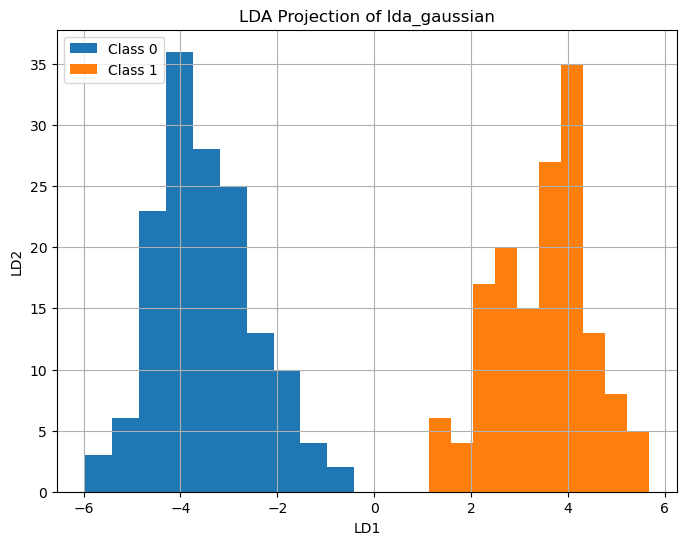

In [33]:
# Plot
class_names = {0: "Class 0", 1: "Class 1"}

plt.figure(figsize=(8,6))
for label in range(0, 2):
    plt.hist(X_lda[y == label, 0], label=class_names[label])
plt.legend()
plt.title("LDA Projection of Ida_gaussian")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.grid(True)
plt.show()
#X_lda[y == label, 1],

### Questions:
###  1.	Do the two classes separate clearly after projection? 
### Ans: Yes, both classes seperate clearly as can be seen from the histogram
### 2.	What property of the dataset helps LDA perform well? 
### Ans: There are three properties of the data set for LDA to perform well:
### a. Gaussian (Normal) distribution: LDA assumes that the features for each class follow a normal distribution.
### b. Indetical covariance: LDA performs best when the classes have similar variance (spread). 
### In the plot, both the blue and orange distributions have a similar width, allowing LDA to find a single optimal linear plane to divide them.
### c. Large Mean Difference vs. Low Within-Class Variance: LDA works by maximizing the distance between class means while minimizing the spread within each class. 
### Data has a significant gap between the centers of the two groups (the "means") and relatively tight clusters, which makes the projection very effective.

### 3.	How are class means positioned in the projected space? 
### Ans: Class means are well seperated
### 4.	Would Principal Component Analysis (PCA) also perform well here? Why or why not? 
### Ans: If the features that distinguish classes (the separation in the histogram) also happen to be the features with the highest variance in the dataset, PCA will capture them.
### In this case there is only one Principle component which presents 100% variance. Hence, PCA will also perfrom well here. 


## Problem 2. Import (non gaussian data) lda_nongaussian
### The objective here is to understand LDA limitations


In [34]:
data_2 = pd.read_csv(r"D:\GenAI\IIT M Pravartak\Content\Assignment\2. 11-Apr-26_LDA\lda_nongaussian.csv")
data_2.head()

,Feature1,Feature2,Label
0,0.803926,-0.291407,1
1,2.314433,-0.122238,1
2,-0.280392,0.450938,1
3,0.789446,0.384060,0
4,1.186657,-0.511438,1


### 1. To check if the features in new data_2 (non-gaussian) dataframe follow a Gaussian distribution, look for two things: visual symmetry and statistical significance.
### 2. Since there are two classes, let us check the distribution per class, as the combined data might look non-Gaussian even if individual classes are normal.

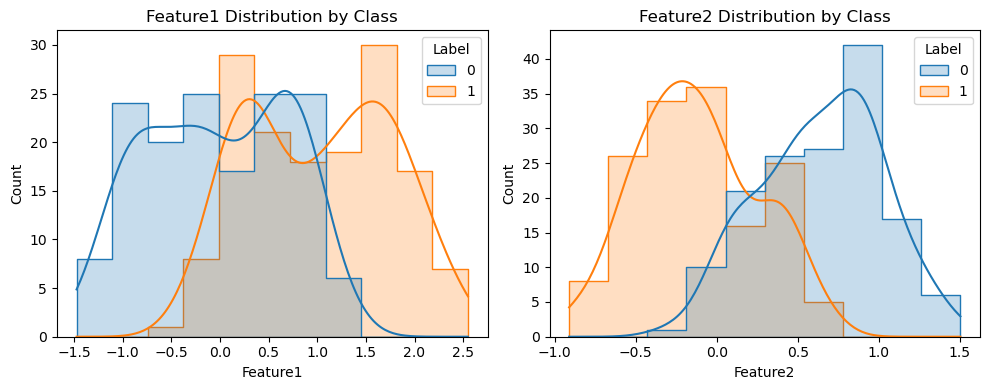

In [35]:
# Check Feature1 distribution for each class
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(data=data_2, x='Feature1', hue='Label', kde=True, element="step")
plt.title("Feature1 Distribution by Class")

plt.subplot(1, 2, 2)
sns.histplot(data=data_2, x='Feature2', hue='Label', kde=True, element="step")
plt.title("Feature2 Distribution by Class")

plt.tight_layout()
plt.show()


### Key findings for distribution of features by class (Visual test to check normal distribution)
### 1. Feature 1: There is high class overlap.So, LDA using only feature 1 could give wrong result.
### 2. Feature 1: shows 2 peaks for class 1 and 1 peak and 1 hump for class 0. Not a true gaussian distribution.
### 3. Feature 2: Shows 1 peak for each class with less overlap between classes. 

In [36]:
# Statistical Check: Shapiro-Wilk Test for normal distribution

from scipy.stats import shapiro

for label in data_2['Label'].unique():
    for feature in ['Feature1', 'Feature2']:
        stat, p = shapiro(data_2[data_2['Label'] == label][feature])
        print(f'Class {label}, {feature}: p-value = {p:.4f}')
        if p > 0.05:
            print("Conclusion: Likely Gaussian")
        else:
            print("Conclusion: Not Gaussian")

Class 1, Feature1: p-value = 0.0001
Conclusion: Not Gaussian
Class 1, Feature2: p-value = 0.0364
Conclusion: Not Gaussian
Class 0, Feature1: p-value = 0.0001
Conclusion: Not Gaussian
Class 0, Feature2: p-value = 0.1920
Conclusion: Likely Gaussian


In [37]:
# Seperate X and y
# Drop Label from data
X1 = data_2.drop(columns=['Label'])
# Select Label
y1 = data_2['Label']

In [38]:
# Apply LDA
lda = LinearDiscriminantAnalysis(n_components=1)
# Using PCA we saw we need two components to capture greater than 95% variance in the data 
# n_components cannot be larger than min(n_features, n_classes - 1).
X1_lda = lda.fit_transform(X1, y1)
B = lda.explained_variance_ratio_
print(B)


[1.]


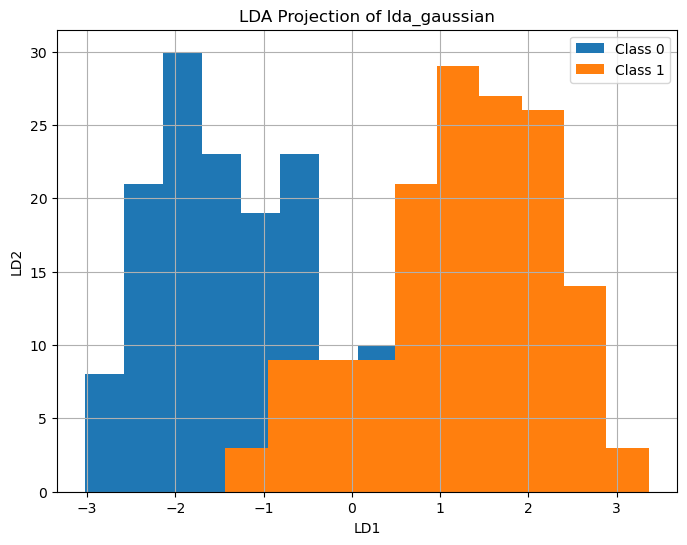

In [39]:
# Plot
class_names = {0: "Class 0", 1: "Class 1"}

plt.figure(figsize=(8,6))
for label in range(0, 2):
    plt.hist(X1_lda[y1 == label, 0], label=class_names[label])
plt.legend()
plt.title("LDA Projection of Ida_gaussian")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.grid(True)
plt.show()

In [40]:
### Questions:

### Q1. Is class separation as clear as in the Gaussian dataset? 
### Ans: No
### Q2.	What assumption of LDA is violated here? 
###: Ans: The assumption that the feature data is normally distributed within each class is violated.
### Q3.	How does the shape of the data affect LDA performance? 
### Ans: Shape of the data represents distribution, between class seperation and within class variance.
### In case data is non-normal, it means, there could be more than one peak. 
### LDA would try to find line seperates centers of the classes. If the center is in a valley, where no data point exists, the projection LDA chooses would not accurately reflect where majority of data lives. 
### Q4.	Would PCA perform better or worse here? Explain. 
### Ans. One of the assumption: PCA assumes that the relationships between variables are linear.
### Since the correlation between variables is weak, even PCA will not work. 

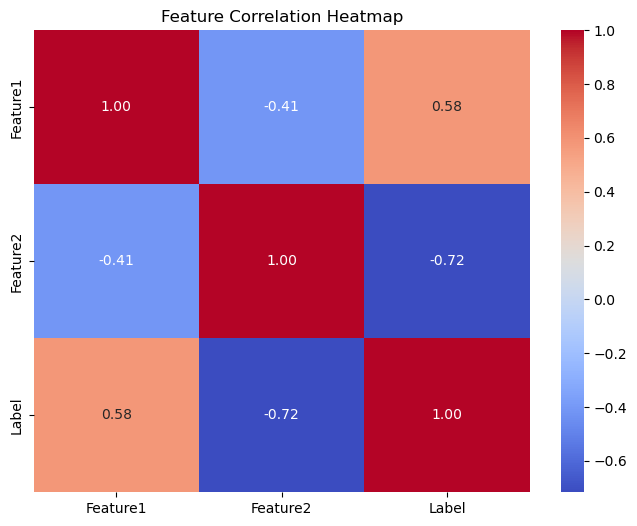

In [41]:
# Calculate the correlation matrix
correlation_matrix = data_2.corr()
# Display it as a Heatmap for easy reading
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

In [42]:
### Steps to manually calculate LDA
### 1. Group Data by Class, Unlike PCA, LDA is supervised. You must separate your feature matrix $X$ based on the class labels $y$. Calculate the mean vector for each class (mu_1, mu_2, ...mu_n) and the overall mean of the entire dataset (mutotal).
### 2. Calculate the Within-Class Scatter Matrix (SW). This represents spread or variance withi class.
### 3. Calculate the Between-Class Scatter Matrix (SB). This matrix represents the distance between the means of different classes. You want this to be large.
### 4. Solve the Generalized Eigenvalue Problem. In PCA, you decompose a single covariance matrix. In LDA, you decompose the matrix that represents the ratio of "Between-Class" to "Within-Class" scatter:S_W^{-1} S_B. You calculate the eigenvalues and eigenvectors for this resulting matrix.
### 5. Step 5: Sort and Select Linear Discriminants (LDs). Sort the eigenvalues in descending order.
### 6. The eigenvector corresponding to the highest eigenvalue is LD1 (the axis that provides the best separation between your classes).

## Problem 3. Import lda_unequal_covariance
### Objective here is to study covariance effect

In [43]:
data_3 = pd.read_csv(r"D:\GenAI\IIT M Pravartak\Content\Assignment\2. 11-Apr-26_LDA\lda_unequal_covariance.csv")
data_3.head()

,Feature1,Feature2,Label
0,0.496714,-0.138264,0
1,0.647689,1.523030,0
2,-0.234153,-0.234137,0
3,1.579213,0.767435,0
4,-0.469474,0.542560,0


In [44]:
# 1. Prepare Data
X = data_3[['Feature1', 'Feature2']].values # X converted to array by using ".values" 
y = data_3['Label'].values
all_mean = np.mean(X, axis=0)

In [45]:
# 2 Scale and center the data
# Calculate mean for each feature (Feature1, Feature2)
mean_f1 = mean_features = np.mean(X, axis=0)
# Calculate standard deviation for each feature
std_features = np.std(X, axis=0)

print(f"Means: {mean_features}")
print(f"Standard Deviations: {std_features}")



Means: [1.49693616 1.49186944]
Standard Deviations: [2.29307078 1.69473543]


In [48]:
# 2 Scaling and centering continues
X_scaled = (X - mean_features) / std_features
# Check the results
print("New mean:", np.mean(X_scaled, axis=0))
print("New std:", np.std(X_scaled, axis=0))

New mean: [ 0.00000000e+00 -9.47390314e-17]
New std: [1. 1.]


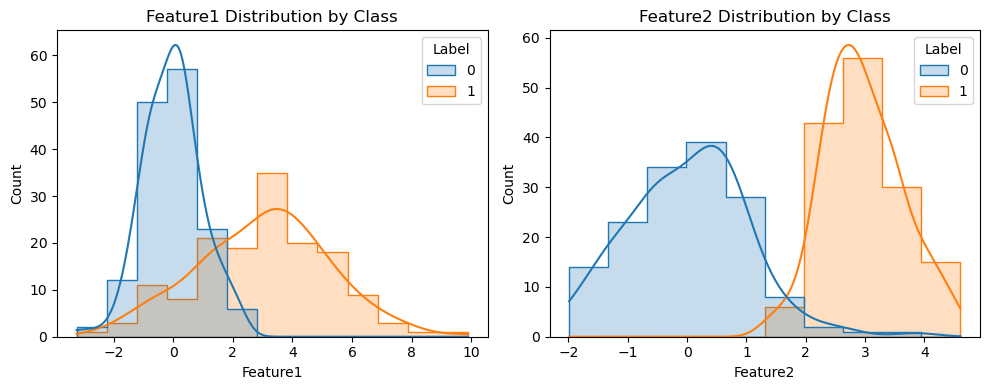

In [59]:
# Create a temporary DataFrame for plotting
df_plot = pd.DataFrame(X, columns=['Feature1', 'Feature2'])
df_plot['Label'] = y
# Check Feature1 distribution for each class
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(data=df_plot, x='Feature1', hue='Label', kde=True, element="step")
plt.title("Feature1 Distribution by Class")

plt.subplot(1, 2, 2)
sns.histplot(data=df_plot, x='Feature2', hue='Label', kde=True, element="step")
plt.title("Feature2 Distribution by Class")

plt.tight_layout()
plt.show()

In [49]:
# View the first 5 rows. Since, X converted to array 
print(y[:5])

[0 0 0 0 0]


In [51]:
# 3. Calculate Class Means and Scatter Matrices
n_features = X.shape[1]
S_W = np.zeros((n_features, n_features))
S_B = np.zeros((n_features, n_features))

for label in np.unique(y):
    # Filter data for this class
    X_c = X[y == label]
    mean_c = np.mean(X_c, axis=0)
    
    # Within-Class Scatter: Sum of (X - mean_c)^2
    # Note: This is essentially the sum of covariance matrices for each class
    S_W += (X_c - mean_c).T.dot(X_c - mean_c)
    
    # Between-Class Scatter: N_c * (mean_c - overall_mean)^2
    n_c = X_c.shape[0]
    mean_diff = (mean_c - all_mean).reshape(n_features, 1)
    S_B += n_c * (mean_diff).dot(mean_diff.T)


# 4. Solve the Generalized Eigenvalue Problem (inv(SW) * SB)
# We want to maximize the ratio of SB to SW
matrix_to_decompose = np.linalg.inv(S_W).dot(S_B)
eigenvalues, eigenvectors = np.linalg.eig(matrix_to_decompose)
print(eigenvalues, eigenvectors)


[0.         3.76989487] [[-0.6923231  -0.24159182]
 [ 0.72158765 -0.97037796]]


In [56]:
# How to read output
#[[-0.6923231,  -0.24159182]  # <--- Feature 1 weights
# [ 0.72158765, -0.97037796]] # <--- Feature 2 weights
#     ^             ^
#  Vector 1      Vector 2 (LD1)

# To create the best axis for separating these classes, take 24% of Feature 1 and 97% of Feature 2.


In [54]:
# Print within class spread and between class disctance
print(S_W)
print(S_B)

[[874.26676925   7.73733897]
 [  7.73733897 214.33302644]]
[[703.18530968 674.66707928]
 [674.66707928 647.30542803]]


In [53]:
# Covariance of X features
print(np.cov(X.T))

[[5.27575946 2.28228902]
 [2.28228902 2.88173396]]


In [ ]:
# Interpretation
# Despite having covariance (spread) for Feature 1 5.27, compared to Feature 2 2.88, 
# the eigen vector [-0.241,  -0.970] is tilted towards toward the second dimension (0.97).
# Analysing within class scatter: Feature 1 Noise S_W11: 874.27, Feature 2 Noise S_W22: 214.33
# Feature 1 has over 4 times more internal noise (spread within the groups) than Feature 2. 
# This massive internal spread "smears" the classes together along the Feature 1 axis, making it very difficult to draw a clean line between them.
# Analysing Feature 1 Signal: S_B11: 703.18, Feature 2 signal: S_B22: 647.30
# The distance between the class means is quite similar. 
# Fisher ratio simplified (Signal/ Noise)
# Feature 1: 703/874 = 0.8
# Feature 2: 647/214 = 3.02

# Conclusion: Feature 2 is roughly 3.7 times more effective at discriminating between classes than Feature 1.


In [57]:
# 5. Sort and Select the Best Eigenvector (LD1)
# Sort by index descending
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# LD1 is the first column
ld1 = eigenvectors[:, 0]

print(f"LD1 Eigenvector: {ld1}")
print(f"LD1 Eigenvalue (Separation Ratio): {eigenvalues[0]}")

# 6. Project the data onto the new LD1 axis
X_lda = X.dot(ld1)

LD1 Eigenvector: [-0.24159182 -0.97037796]
LD1 Eigenvalue (Separation Ratio): 3.769894872125006


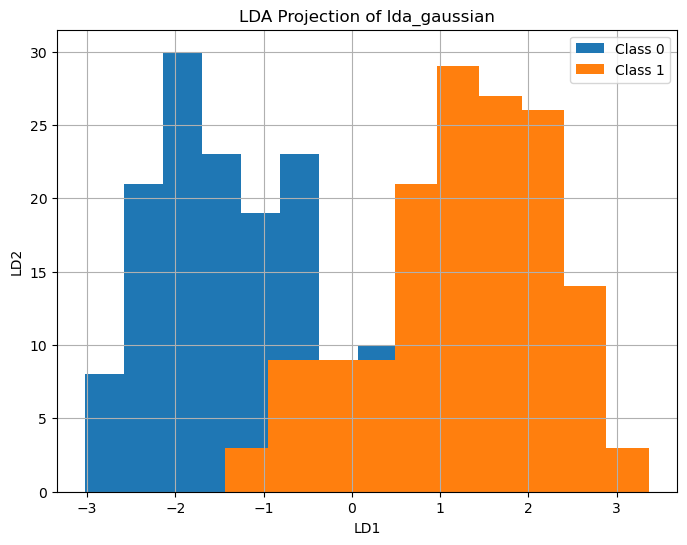

In [61]:
# LDA Projection
class_names = {0: "Class 0", 1: "Class 1"}

plt.figure(figsize=(8,6))
for label in range(0, 2):
    plt.hist(X1_lda[y1 == label, 0], label=class_names[label])
plt.legend()
plt.title("LDA Projection of Ida_gaussian")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.grid(True)
plt.show()

### Problem 4. Import lda_multiclass.csv
#### The objective here is to understand component limitation

In [156]:
data_4 = pd.read_csv(r"D:\GenAI\IIT M Pravartak\Content\Assignment\2. 11-Apr-26_LDA\lda_multiclass.csv")
data_4.head()

,F1,F2,F3,F4,F5,Label
0,-8.467584,-0.777407,1.551185,-1.137861,-4.230311,3
1,-1.351087,9.805949,5.263999,2.601515,-6.891874,0
2,-3.957282,7.606822,3.921435,1.759723,-6.568720,0
3,-7.332416,-11.262207,5.739620,2.782715,4.947252,1
4,-8.669234,9.107922,6.916245,-5.431520,-7.031591,2


In [157]:
X = data_4[['F1', 'F2', 'F3', 'F4', 'F5']].copy()

In [158]:
X.head()

,F1,F2,F3,F4,F5
0,-8.467584,-0.777407,1.551185,-1.137861,-4.230311
1,-1.351087,9.805949,5.263999,2.601515,-6.891874
2,-3.957282,7.606822,3.921435,1.759723,-6.568720
3,-7.332416,-11.262207,5.739620,2.782715,4.947252
4,-8.669234,9.107922,6.916245,-5.431520,-7.031591


In [159]:
y = data_4[['Label']].copy()

In [160]:
print(type(y))

<class 'pandas.core.frame.DataFrame'>


In [161]:
y_arr = y.to_numpy().flatten()

In [162]:
unique_values = np.unique(y_arr)
print(unique_values)

[0 1 2 3]


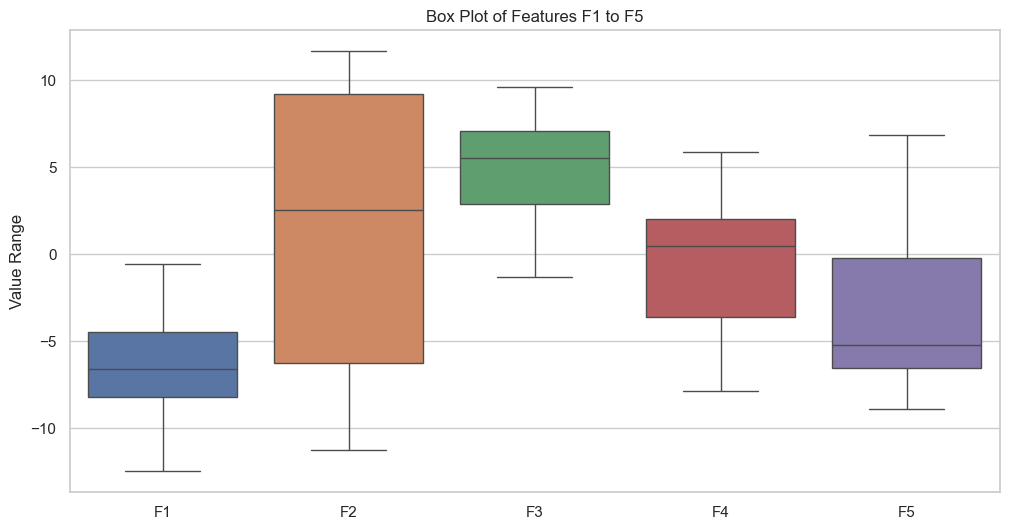

In [163]:
# Set the style
sns.set_theme(style="whitegrid")

# Create a boxplot for all features in X
plt.figure(figsize=(12, 6))
sns.boxplot(data=X)
plt.title("Box Plot of Features F1 to F5")
plt.ylabel("Value Range")
plt.show()

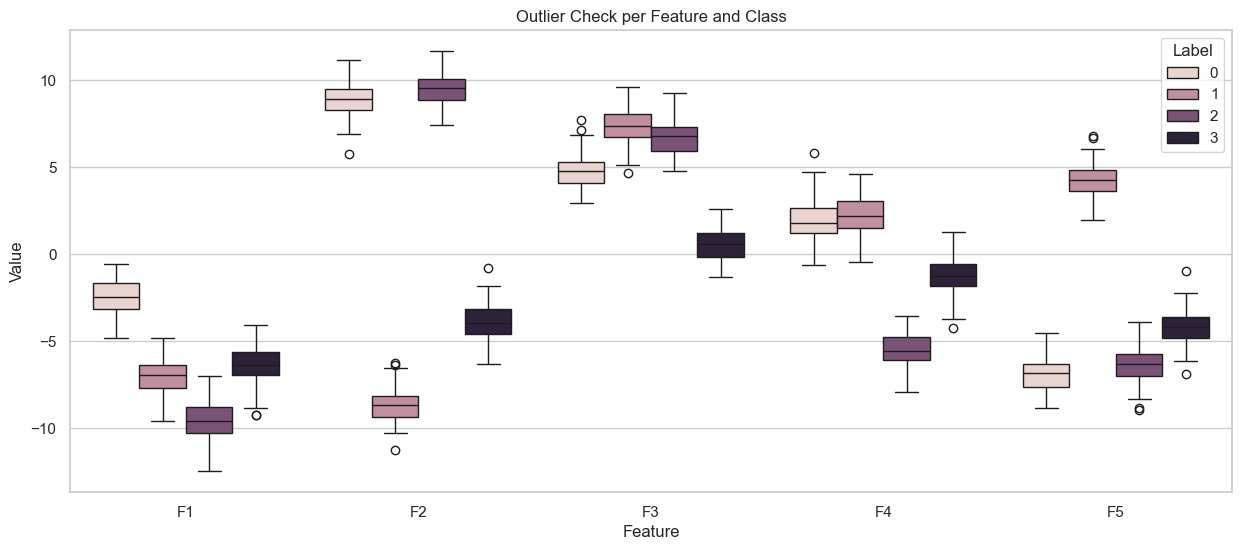

In [164]:
# Identifying Outlier by class
# Melt the data to make it compatible with Seaborn's hue
df_melted = data_4.melt(id_vars='Label', var_name='Feature', value_name='Value')

plt.figure(figsize=(15, 6))
sns.boxplot(data=df_melted, x='Feature', y='Value', hue='Label')
plt.title("Outlier Check per Feature and Class")
plt.show()

In [165]:
# Scale and center the data 
# 1. Initialize the scaler
scaler = StandardScaler()
# 2. Fit and transform the data
# This calculates mu and sigma and applies the formula in one step
X_scaled = scaler.fit_transform(X)

# 3. (Optional) Converting back to a DataFrame for keeping column names and plotting
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Verify the results
print(f"Mean of scaled data: {np.round(X_scaled.mean(axis=0), 2)}")
print(f"Std deviation of scaled data: {X_scaled.std(axis=0)}")


Mean of scaled data: [-0. -0. -0.  0. -0.]
Std deviation of scaled data: [1. 1. 1. 1. 1.]


In [166]:
print(X_scaled)

[[-0.77 -0.28 -1.16 -0.15 -0.2 ]
 [ 1.81  1.05  0.15  0.99 -0.78]
 [ 0.86  0.77 -0.32  0.73 -0.71]
 ...
 [ 1.46  0.87 -0.04  0.68 -0.75]
 [-0.68  1.07  0.85 -1.3  -0.5 ]
 [-0.31  0.99  0.71 -1.24 -0.42]]


In [167]:
X_scaled_df.head()

,F1,F2,F3,F4,F5
0,-0.771312,-0.280116,-1.157522,-0.151420,-0.198375
1,1.805051,1.045869,0.153999,0.992029,-0.782003
2,0.861539,0.770341,-0.320251,0.734621,-0.711141
3,-0.360351,-1.593754,0.322008,1.047438,1.814083
4,-0.844315,0.958414,0.737641,-1.464361,-0.812640


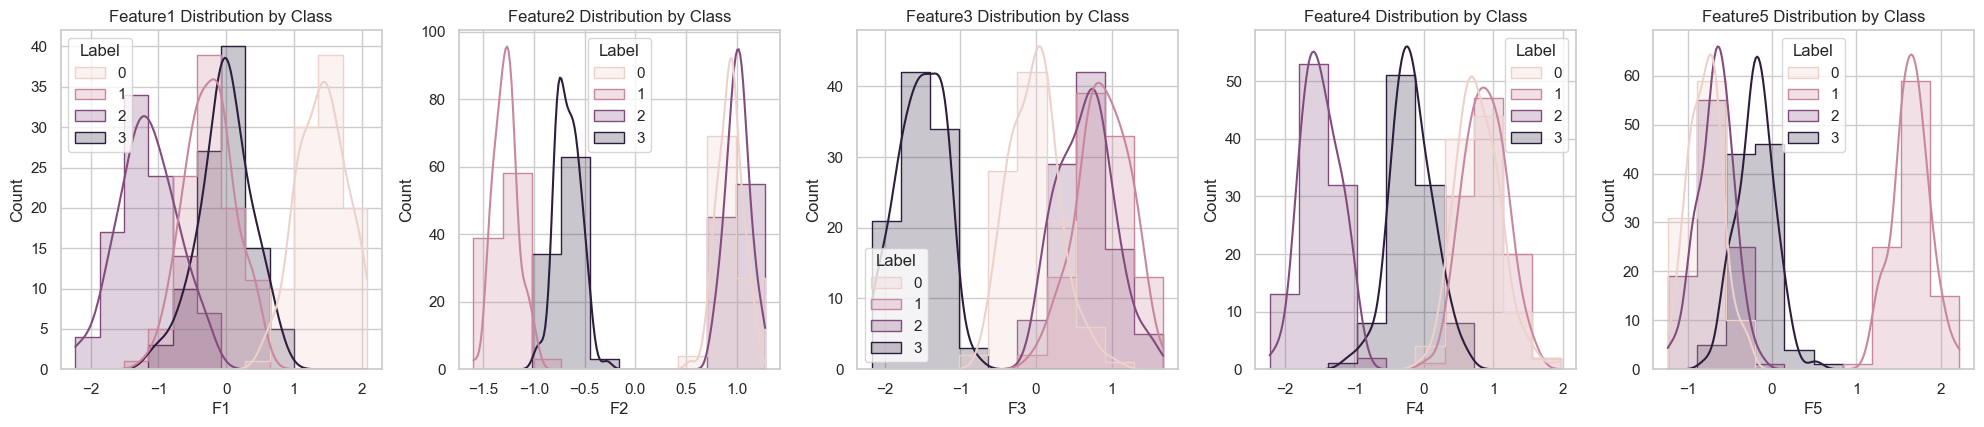

In [168]:
# Create a temporary DataFrame for plotting
# df_plot = pd.DataFrame(X, columns=['Feature1', 'Feature2'])
X_scaled_df['Label'] = y
# Check Feature1 distribution for each class
plt.figure(figsize=(20, 8))

plt.subplot(2, 5, 1)
sns.histplot(data=X_scaled_df, x='F1', hue='Label', kde=True, element="step")
plt.title("Feature1 Distribution by Class")

plt.subplot(2, 5, 2)
sns.histplot(data=X_scaled_df, x='F2', hue='Label', kde=True, element="step")
plt.title("Feature2 Distribution by Class")

plt.subplot(2, 5, 3)
sns.histplot(data=X_scaled_df, x='F3', hue='Label', kde=True, element="step")
plt.title("Feature3 Distribution by Class")

plt.subplot(2, 5, 4)
sns.histplot(data=X_scaled_df, x='F4', hue='Label', kde=True, element="step")
plt.title("Feature4 Distribution by Class")

plt.subplot(2, 5, 5)
sns.histplot(data=X_scaled_df, x='F5', hue='Label', kde=True, element="step")
plt.title("Feature5 Distribution by Class")

plt.tight_layout()
plt.show()

In [169]:
# Fit LDA with sklearn
lda = LinearDiscriminantAnalysis(n_components=3)
lda.fit(X_scaled, y_arr)

# Manually compute eigenvalues and eigenvectors (same as in previous code)
class_labels = np.unique(y_arr)
mean_overall = np.mean(X_scaled, axis=0)
n_features = X_scaled.shape[1]
S_W = np.zeros((n_features, n_features))
S_B = np.zeros((n_features, n_features))

for label in class_labels:
    X_class = X_scaled[y_arr == label]
    mean_class = np.mean(X_class, axis=0)
    # Within-class scatter
    S_W += np.dot((X_class - mean_class).T, (X_class - mean_class))
    # Between-class scatter
    n_class_samples = X_class.shape[0]
    mean_diff = (mean_class - mean_overall).reshape(n_features, 1)
    S_B += n_class_samples * (mean_diff).dot(mean_diff.T)

# Solve generalized eigenvalue problem
eig_vals, eig_vecs = np.linalg.eig(np.linalg.inv(S_W).dot(S_B))

# Extract real parts of eigenvalues and eigenvectors
eig_vals = np.real(eig_vals)
eig_vecs = np.real(eig_vecs)

# Sort eigenvectors by eigenvalues
sorted_indices = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[sorted_indices]
eig_vecs = eig_vecs[:, sorted_indices]

In [170]:
# suppress=True prevents scientific notation, precision=4 sets decimals
np.set_printoptions(suppress=True, precision=2)

print(eig_vals * 100)

[8925.94 1317.57 1189.5     0.      0.  ]


In [171]:
print(eig_vecs)

[[ 0.01 -0.15 -0.45  0.37  0.37]
 [ 0.95  0.54 -0.49  0.37  0.37]
 [-0.02  0.58 -0.14 -0.2  -0.2 ]
 [-0.09 -0.04 -0.72 -0.43 -0.43]
 [-0.29  0.59 -0.17  0.68  0.68]]


In [172]:
# Print LDA eigenvalues (explained variance ratio)
A = lda.explained_variance_ratio_
print("LDA explained variance ratio:", A)

# Access the scaling (eigenvectors)
B = lda.scalings_[:, :3]
print("LDA components (scaling or eigenvectors):", B)


LDA explained variance ratio: [0.78 0.12 0.1 ]
LDA components (scaling or eigenvectors): [[ 0.06 -0.64 -1.51]
 [ 7.2   2.22 -1.64]
 [-0.16  2.37 -0.47]
 [-0.69 -0.16 -2.43]
 [-2.17  2.44 -0.57]]


In [173]:
# 2 lines of code using Fit and Transform
lda = LinearDiscriminantAnalysis(n_components=3) # why 2?????
# Selecting the top n_components eigenvectors (those with highest eigenvalues)
# Projecting your data onto those vectors
# These eigenvectors become your new discriminant axes (LD1, LD2, etc).
X_lda = lda.fit_transform(X_scaled, y_arr)

A = lda.explained_variance_ratio_
print(A)

[0.78 0.12 0.1 ]


In [174]:
# Create a DataFrame of the actual Eigenvectors
# These are the coefficients (weights) for your projection
components_df = pd.DataFrame(
    B, 
    index=['F1', 'F2', 'F3', 'F4', 'F5'], 
    columns=['LD1', 'LD2', 'LD3']
)

print("LDA Feature Weights (Components):")
display(components_df)

LDA Feature Weights (Components):


,LD1,LD2,LD3
F1,0.063713,-0.635659,-1.505866
F2,7.204973,2.216353,-1.639554
F3,-0.162350,2.369579,-0.466332
F4,-0.687390,-0.157938,-2.426350
F5,-2.173622,2.437348,-0.568679


IndexError: index 2 is out of bounds for axis 1 with size 2

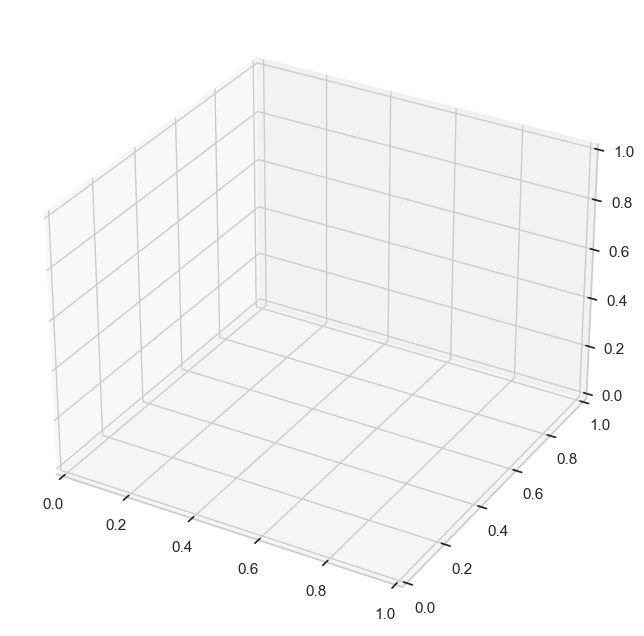

In [175]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot each feature as a vector
for i, feature in enumerate(components_df.index):
    # Get the LD1, LD2, LD3 weights for this feature
    x, y, z = lda_components[i, 0], lda_components[i, 1], lda_components[i, 2]
    
    # Draw a line from origin to the component coordinate
    ax.quiver(0, 0, 0, x, y, z, color='red', alpha=0.8, arrow_length_ratio=0.1)
    ax.text(x * 1.2, y * 1.2, z * 1.2, feature, color='black', fontweight='bold')

ax.set_xlabel('LD1')
ax.set_ylabel('LD2')
ax.set_zlabel('LD3')
ax.set_title('Feature Contribution to LD Components')

# Adjust limits to see vectors clearly
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])

plt.show()

In [ ]:
# The goal of LDA is to find axes that maximize the distance between the means of classes.
# LDA can provide maximum components = mimimum of (d, (n-1)), LDA components. d = number of features and n = number of class labels in the output
# Any component beyond the (n-1)th one would have an eigenvalue of zero because there is no more "between-class" variance left to capture.